<a href="https://colab.research.google.com/github/LuizaRamos/TOL506M_Final_Project/blob/main/notebooks/04_learning_curves.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# TÖL506M - Introduction to Deep Neural Network
## Final Project: Wildlife Image Classification
### Learning Curves
**name:** Luiza V Sampaio Ramos, **email:** lvs2@gmail.com



WRITE SOMETHING

**Observation:** The first cell of code bellow was implemente to be able to run the notebook using Google Colab, while the rest o the code was initially wroten using DataSpell.

In [1]:
!rm -rf /content/TOL506M_Final_Project

In [2]:
import os, sys, subprocess

REPO_URL = "https://github.com/LuizaRamos/TOL506M_Final_Project.git"
REPO_DIR = "/content/TOL506M_Final_Project"

# Always clone fresh in Colab
subprocess.run(["git", "clone", REPO_URL, REPO_DIR], check=True)

os.chdir(REPO_DIR)

if REPO_DIR not in sys.path:
    sys.path.insert(0, REPO_DIR)
os.environ["PYTHONPATH"] = REPO_DIR + os.pathsep + os.environ.get("PYTHONPATH", "")

In [3]:
import sys
import os
import subprocess
import importlib
import json
import time
import random
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from pathlib import Path
from collections import Counter
from PIL import Image
from typing import Dict, List, Tuple

import torch
import torch.nn as nn
from torch.utils.data import Subset, DataLoader
from torchvision import datasets, transforms
import torch.optim as optim
from torch.optim.lr_scheduler import ReduceLROnPlateau, CosineAnnealingLR

project_root = Path.cwd()
if project_root.name != "TOL506M_Final_Project":
    original = project_root
    while project_root.name != "TOL506M_Final_Project" and project_root != project_root.parent:
        project_root = project_root.parent

    if project_root.name == "TOL506M_Final_Project":
        os.chdir(project_root)
        print(f"Changed working directory from {original} to {project_root}")
    else:
        raise RuntimeError(
            "Could not locate the TOL506M_Final_Project root directory. "
            "Please run this notebook/script from within the project tree."
        )
else:
    print(f"Working directory: {project_root}")

if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

# Plot styling
sns.set_style("whitegrid")
plt.rcParams.update({"figure.figsize": (12, 6), "font.size": 12})

print(f"\nPyTorch version: {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")

Working directory: /content/TOL506M_Final_Project

PyTorch version: 2.9.0+cu126
CUDA available: True


   Data_Fraction  Average_Minutes  Uncertainty_SD
0           0.10        21.265638        6.643188
1           0.25        44.123553       11.634633
2           0.50        74.967911       19.695719
3           0.75        90.913256       30.492287
4           1.00        94.781169        2.085547


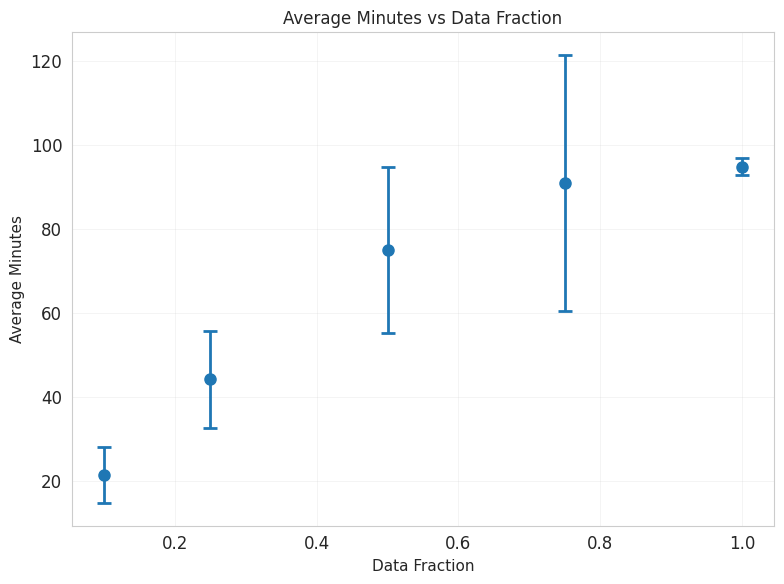

In [6]:
import pandas as pd

# Read JSON file
with open('/content/TOL506M_Final_Project/results/metrics/task1_scratch_all_fractions_summary.json', 'r') as f:
    task1_1 = json.load(f)

with open("/content/TOL506M_Final_Project/results/metrics/task1_scratch_all_fractions_summary_42.json", 'r') as f:
    task1_2 = json.load(f)

with open('/content/TOL506M_Final_Project/results/metrics/task1_scratch_all_fractions_summary_640.json', 'r') as f:
    task1_3 = json.load(f)

#with open('/content/TOL506M_Final_Project/results/metrics/task2_1.json', 'r') as f:
#    task2_1 = json.load(f)

#with open('/content/TOL506M_Final_Project/results/metrics/task2_42.json', 'r') as f:
#    task2_2 = json.load(f)

#with open('/content/TOL506M_Final_Project/results/metrics/task2_640.json', 'r') as f:
#    task2_3 = json.load(f)

with open('/content/TOL506M_Final_Project/results/metrics/task3_1.json', 'r') as f:
    task3_1 = json.load(f)

with open('/content/TOL506M_Final_Project/results/metrics/task3_42.json', 'r') as f:
    task3_2 = json.load(f)

with open('/content/TOL506M_Final_Project/results/metrics/task3_640.json', 'r') as f:
    task3_3 = json.load(f)

# Get one variable from the JSON data and copy to a new variable
t1_1 = [item['training_time'] for item in task1_1]
t1_2 = [item['training_time'] for item in task1_2]
t1_3 = [item['training_time'] for item in task1_3]
#t2_1 = [item['training_time'] for item in task2_1]
#t2_2 = [item['training_time'] for item in task2_2]
#t2_3 = [item['training_time'] for item in task2_3]
t3_1 = [item['training_time'] for item in task3_1]
t3_2 = [item['training_time'] for item in task3_2]
t3_3 = [item['training_time'] for item in task3_3]

# Convert from seconds to minutes
t1_1_min = np.array(t1_1) / 60
t1_2_min = np.array(t1_2) / 60
t1_3_min = np.array(t1_3) / 60
#t2_1_min = np.array(t2_1) / 60
#t2_2_min = np.array(t2_2) / 60
#t2_3_min = np.array(t2_3) / 60
t3_1_min = np.array(t3_1) / 60
t3_2_min = np.array(t3_2) / 60
t3_3_min = np.array(t3_3) / 60


# Combine measurements into a matrix (each column is a measurement set)
combined_times = np.column_stack([t1_1_min, t1_2_min, t1_3_min])
average_time = np.mean(combined_times, axis=1)
uncertainty = np.std(combined_times, axis=1, ddof=1)

results = pd.DataFrame({
    'Data_Fraction': [0.1, 0.25, 0.5, 0.75, 1.0],
    'Average_Minutes': average_time,
    'Uncertainty_SD': uncertainty
})

# Create plot
plt.figure(figsize=(8, 6))
plt.errorbar(results['Data_Fraction'], results['Average_Minutes'],
             yerr=results['Uncertainty_SD'],
             fmt='o', markersize=8, capsize=5, capthick=2, linewidth=2)
plt.xlabel('Data Fraction', fontsize=11)
plt.ylabel('Average Minutes', fontsize=11)
plt.title('Average Minutes vs Data Fraction', fontsize=12)
plt.grid(True, alpha=0.3, linestyle='-', linewidth=0.5)
plt.tight_layout()
plt.show()

Task 2 files not found, skipping task 2 in the plot


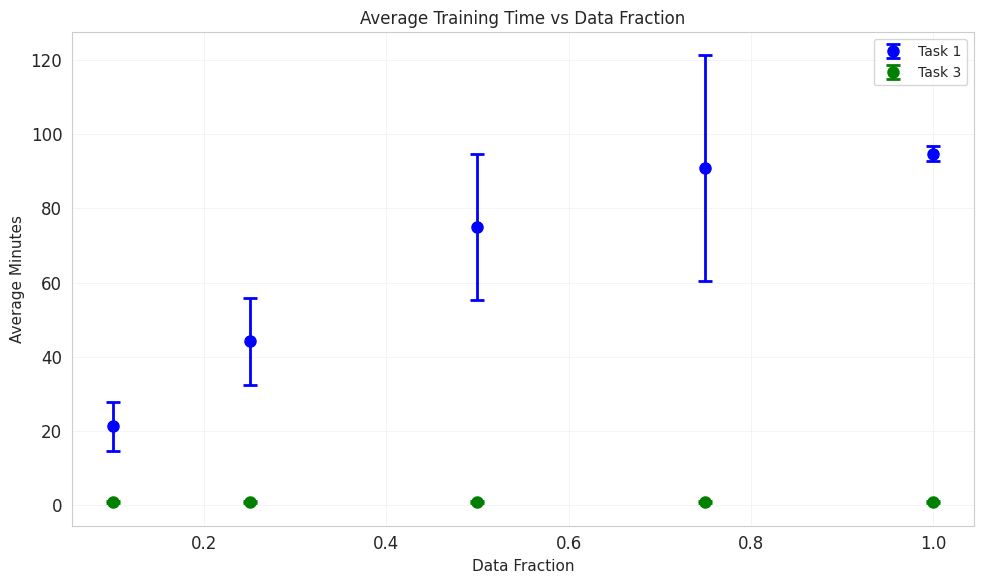

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import json

# Read JSON file
with open('/content/TOL506M_Final_Project/results/metrics/task1_scratch_all_fractions_summary.json', 'r') as f:
    task1_1 = json.load(f)

with open("/content/TOL506M_Final_Project/results/metrics/task1_scratch_all_fractions_summary_42.json", 'r') as f:
    task1_2 = json.load(f)

with open('/content/TOL506M_Final_Project/results/metrics/task1_scratch_all_fractions_summary_640.json', 'r') as f:
    task1_3 = json.load(f)

# Try to load task2 files if available
try:
    with open('/content/TOL506M_Final_Project/results/metrics/task2_1.json', 'r') as f:
        task2_1 = json.load(f)
    with open('/content/TOL506M_Final_Project/results/metrics/task2_42.json', 'r') as f:
        task2_2 = json.load(f)
    with open('/content/TOL506M_Final_Project/results/metrics/task2_640.json', 'r') as f:
        task2_3 = json.load(f)
    task2_available = True
except FileNotFoundError:
    task2_available = False
    print("Task 2 files not found, skipping task 2 in the plot")

with open('/content/TOL506M_Final_Project/results/metrics/task3_1.json', 'r') as f:
    task3_1 = json.load(f)

with open('/content/TOL506M_Final_Project/results/metrics/task3_42.json', 'r') as f:
    task3_2 = json.load(f)

with open('/content/TOL506M_Final_Project/results/metrics/task3_640.json', 'r') as f:
    task3_3 = json.load(f)

# Extract training times for Task 1
t1_1 = [item['training_time'] for item in task1_1]
t1_2 = [item['training_time'] for item in task1_2]
t1_3 = [item['training_time'] for item in task1_3]

# Extract training times for Task 2 (if available)
if task2_available:
    t2_1 = [item['training_time'] for item in task2_1]
    t2_2 = [item['training_time'] for item in task2_2]
    t2_3 = [item['training_time'] for item in task2_3]

# Data fractions
data_fractions = [0.1, 0.25, 0.5, 0.75, 1.0]

# Extract inference times for Task 3
# Correcting the extraction as task3_X are dictionaries, not lists.
# Assuming 'zero_shot' inference time is desired and replicating it for all data fractions.
# If task3_X were lists of dictionaries per data fraction, this extraction would be different.
t3_1 = [task3_1['zero_shot']['inference_time']] * len(data_fractions)
t3_2 = [task3_2['zero_shot']['inference_time']] * len(data_fractions)
t3_3 = [task3_3['zero_shot']['inference_time']] * len(data_fractions)

# Convert from seconds to minutes - Task 1
t1_1_min = np.array(t1_1) / 60
t1_2_min = np.array(t1_2) / 60
t1_3_min = np.array(t1_3) / 60

# Convert from seconds to minutes - Task 2 (if available)
if task2_available:
    t2_1_min = np.array(t2_1) / 60
    t2_2_min = np.array(t2_2) / 60
    t2_3_min = np.array(t2_3) / 60

# Convert from seconds to minutes - Task 3
t3_1_min = np.array(t3_1) / 60
t3_2_min = np.array(t3_2) / 60
t3_3_min = np.array(t3_3) / 60

# Calculate averages and uncertainties for Task 1
combined_times_t1 = np.column_stack([t1_1_min, t1_2_min, t1_3_min])
average_time_t1 = np.mean(combined_times_t1, axis=1)
uncertainty_t1 = np.std(combined_times_t1, axis=1, ddof=1)

# Calculate averages and uncertainties for Task 2 (if available)
if task2_available:
    combined_times_t2 = np.column_stack([t2_1_min, t2_2_min, t2_3_min])
    average_time_t2 = np.mean(combined_times_t2, axis=1)
    uncertainty_t2 = np.std(combined_times_t2, axis=1, ddof=1)

# Calculate averages and uncertainties for Task 3
combined_times_t3 = np.column_stack([t3_1_min, t3_2_min, t3_3_min])
average_time_t3 = np.mean(combined_times_t3, axis=1)
uncertainty_t3 = np.std(combined_times_t3, axis=1, ddof=1)

# Create plot
plt.figure(figsize=(10, 6))

# Plot Task 1 (blue)
plt.errorbar(data_fractions, average_time_t1,
             yerr=uncertainty_t1,
             fmt='o', markersize=8, capsize=5, capthick=2, linewidth=2,
             color='blue', label='Task 1')

# Plot Task 2 (red) if available
if task2_available:
    plt.errorbar(data_fractions, average_time_t2,
                 yerr=uncertainty_t2,
                 fmt='o', markersize=8, capsize=5, capthick=2, linewidth=2,
                 color='red', label='Task 2')

# Plot Task 3 (green)
plt.errorbar(data_fractions, average_time_t3,
             yerr=uncertainty_t3,
             fmt='o', markersize=8, capsize=5, capthick=2, linewidth=2,
             color='green', label='Task 3')

plt.xlabel('Data Fraction', fontsize=11)
plt.ylabel('Average Minutes', fontsize=11)
plt.title('Average Training Time vs Data Fraction', fontsize=12)
plt.legend(fontsize=10)
plt.grid(True, alpha=0.3, linestyle='-', linewidth=0.5)
plt.tight_layout()
plt.show()